# Berm Condition & Vegetation — RF Model Approaches

Feature selection and random-forest model comparisons for condition and vegetation response outcomes.
Loads `../data/merged.csv` produced by `data processing - condition vegetation.ipynb`.



In [ ]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL,
    eff_colors,
    LBL_EFFECTIVE,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn(\..*)?')
from IPython.display import display
pd.set_option('display.max_columns', 50)


In [2]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'Condition'

In [ ]:
from registry import register_outcomes_figure
from analysis import fit_rf_binary


In [ ]:
from analysis import _unique_preserve

# Working copy: drop artificial structures if present
df = data.loc[data["Structure_"].isna()].copy() if "Structure_" in data.columns else data.copy()

print(f"df: {len(df):,} rows")


df: 743 rows   |   predictors ranked: 17


## Feature selection, model comparison

here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
and then train alternative models with the 

In [ ]:
# ── predictor scenario definitions ───────────────────────────────────────────
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

_geo_preds  = ["Landform", "slope_200", "FA_30_max"]
_soil_preds = ["Texture", "Soil_Development", "TypicalProfile"]
_len_preds  = ["Shape_Leng", "Berm_Length_Class"]
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    "landscape_geomorphology_only": _geo_preds,
    "soil_only":                    _soil_preds,
    "shape_length_only":            _len_preds,
    "all_predictors":               _all_preds,
}

_targets = ["Intact", "Effective"]

# ── run all scenarios ─────────────────────────────────────────────────────────
os.makedirs("../data/summary", exist_ok=True)
results_txt = "../data/summary/scenario_model_results.txt"
summary_rows = []
_log_lines = []

for _scenario_name, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f"Skipping '{_scenario_name}': no predictors found in df.columns")
        continue
    for _target in _targets:
        _log_lines.append(f"\n\n######## {_scenario_name} / {_target} ########")
        _log_lines.append(f"Predictors: {_preds_run}")
        try:
            _model, _metrics, _pi = fit_rf_binary(
                df, y=_target, predictors=_preds_run, treat_as=treat_as
            )
        except Exception as _e:
            _log_lines.append(f"  SKIP: {_e}")
            print(f"Skipping '{_scenario_name}' / {_target}: {_e}")
            continue

        _top3 = ", ".join(_pi.head(min(3, len(_pi))).index.tolist())
        _log_lines.append(
            f"  cv_auc = {_metrics['cv']['auc'][0]:.4f} ± {_metrics['cv']['auc'][1]:.4f}"
            f"  top3 = {_top3}"
        )
        summary_rows.append({
            "scenario":        _scenario_name,
            "target":          _target,
            "cv_auc_mean":     _metrics["cv"]["auc"][0],
            "cv_auc_sd":       _metrics["cv"]["auc"][1],
            "holdout_auc":     _metrics["holdout"]["auc"],
            "cv_bal_acc_mean": _metrics["cv"]["bal_acc"][0],
            "cv_f1_mean":      _metrics["cv"]["f1"][0],
            "top_3_predictors": _top3,
            "n":               _metrics["n"],
            "n_predictors":    len(_preds_run),
        })

with open(results_txt, "w") as _f:
    _f.write("\n".join(_log_lines))

print(f"Done — {len(summary_rows)} scenario/target combinations run.")
print(f"Results saved to {results_txt}")


Done — 8 scenario/target combinations run.
Results saved to ../data/summary/scenario_model_results.txt


In [7]:
# ── Create binary predictor versions for simplified RF ────────────────────────
# Binary versions: high vs low slope, long vs short berm
df_binary = df.copy()

# Create binary slope (using median as threshold)
slope_median = df_binary['slope_200'].median()
df_binary['High_Slope'] = (df_binary['slope_200'] > slope_median).astype(str)
df_binary.loc[df_binary['slope_200'] > slope_median, 'High_Slope'] = 'High slope'
df_binary.loc[df_binary['slope_200'] <= slope_median, 'High_Slope'] = 'Low slope'

# Create binary length (using median as threshold)
length_median = df_binary['Shape_Leng'].median()
df_binary['Long_Berm'] = (df_binary['Shape_Leng'] > length_median).astype(str)
df_binary.loc[df_binary['Shape_Leng'] > length_median, 'Long_Berm'] = 'Long'
df_binary.loc[df_binary['Shape_Leng'] <= length_median, 'Long_Berm'] = 'Short'

print(f"Binary predictors created:")
print(f"  Slope median: {slope_median:.2f} → High_Slope")
print(f"  Length median: {length_median:.1f} → Long_Berm")
print(f"\nHigh_Slope distribution:")
print(df_binary['High_Slope'].value_counts())
print(f"\nLong_Berm distribution:")
print(df_binary['Long_Berm'].value_counts())

Binary predictors created:
  Slope median: 1.89 → High_Slope
  Length median: 60.3 → Long_Berm

High_Slope distribution:
High_Slope
Low slope     372
High slope    371
Name: count, dtype: int64

Long_Berm distribution:
Long_Berm
Short    372
Long     371
Name: count, dtype: int64


In [8]:
# ── Train RF with FULL predictors (all_predictors) ──────────────────────────
full_predictors = scenario_predictors["all_predictors"]
full_treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

results_full = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training FULL model for {target}")
    print(f"{'='*60}")
    model_full, metrics_full, importance_full = fit_rf_binary(
        df, y=target, predictors=full_predictors, treat_as=full_treat_as
    )
    results_full[target] = {
        "model": model_full,
        "metrics": metrics_full,
        "importance": importance_full,
        "predictors": full_predictors
    }
    print(f"Full model CV AUC: {metrics_full['cv']['auc'][0]:.3f} ± {metrics_full['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_full.head(3).index.tolist())}")


Training FULL model for Intact
Full model CV AUC: 0.728 ± 0.011
Top 3 predictors: FA_30_max, Shape_Leng, slope_200

Training FULL model for Effective
Full model CV AUC: 0.652 ± 0.044
Top 3 predictors: slope_200, Berm_Length_Class, Texture


### Random Forest Comparison: Full vs Binary Predictors

We train two random forests for comparison:
1. **Full model**: All continuous and categorical predictors (slope_200, Shape_Leng, landform, soil texture, etc.)
2. **Binary model**: Simplified binary versions (high/low slope, long/short berm, plus key categorical variables)
   
This comparison helps interpret the random forest feature importance by testing whether simplified binary predictors capture the main signal, allowing clearer interpretation of which factors drive berm outcomes.

In [9]:
# ── Train RF with BINARY predictors (simplified) ───────────────────────────
# Use simplified binary predictors: High_Slope, Long_Berm, plus key categoricals
binary_predictors = [
    "High_Slope",     # binary: high vs low slope
    "Long_Berm",      # binary: long vs short berm
    "Landform",       # categorical (already 3 levels)
    "Soil_Development",  # categorical (2 levels)
    "Texture",        # categorical
]

binary_treat_as = {}  # all categorical for binary model

results_binary = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training BINARY model for {target}")
    print(f"{'='*60}")
    model_binary, metrics_binary, importance_binary = fit_rf_binary(
        df_binary, y=target, predictors=binary_predictors, treat_as=binary_treat_as
    )
    results_binary[target] = {
        "model": model_binary,
        "metrics": metrics_binary,
        "importance": importance_binary,
        "predictors": binary_predictors
    }
    print(f"Binary model CV AUC: {metrics_binary['cv']['auc'][0]:.3f} ± {metrics_binary['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_binary.head(3).index.tolist())}")


Training BINARY model for Intact
Binary model CV AUC: 0.614 ± 0.012
Top 3 predictors: Long_Berm, Texture, Soil_Development

Training BINARY model for Effective
Binary model CV AUC: 0.635 ± 0.028
Top 3 predictors: High_Slope, Texture, Soil_Development


In [10]:
# ── Create comparison summary table ─────────────────────────────────────────
comparison_rows = []
for target in ["Intact", "Effective"]:
    # Full model
    m_full = results_full[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Full",
        "N_predictors": len(results_full[target]["predictors"]),
        "CV_AUC_mean": m_full["cv"]["auc"][0],
        "CV_AUC_sd": m_full["cv"]["auc"][1],
        "Holdout_AUC": m_full["holdout"]["auc"],
        "CV_BalAcc": m_full["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_full[target]["importance"].head(3).index.tolist())
    })
    # Binary model
    m_bin = results_binary[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Binary",
        "N_predictors": len(results_binary[target]["predictors"]),
        "CV_AUC_mean": m_bin["cv"]["auc"][0],
        "CV_AUC_sd": m_bin["cv"]["auc"][1],
        "Holdout_AUC": m_bin["holdout"]["auc"],
        "CV_BalAcc": m_bin["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_binary[target]["importance"].head(3).index.tolist())
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*80)
print("RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors")
print("="*80)
display(comparison_df)

# Save comparison table
comparison_path = "../data/summary/rf_full_vs_binary_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison table saved to {comparison_path}")


RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors


,Target,Model,N_predictors,CV_AUC_mean,CV_AUC_sd,Holdout_AUC,CV_BalAcc,Top_3
0,Intact,Full,8,0.727806,0.010714,0.771605,0.656144,"FA_30_max, Shape_Leng, slope_200"
1,Intact,Binary,5,0.614473,0.011714,0.683345,0.590019,"Long_Berm, Texture, Soil_Development"
2,Effective,Full,8,0.651622,0.044287,0.645988,0.609234,"slope_200, Berm_Length_Class, Texture"
3,Effective,Binary,5,0.635389,0.028120,0.643727,0.615996,"High_Slope, Texture, Soil_Development"



Comparison table saved to ../data/summary/rf_full_vs_binary_comparison.csv


Updated → ../latex/figure_report_outcomes.tex  (RF Full — feature importance)
Saved: fig_rf_full_importance.png


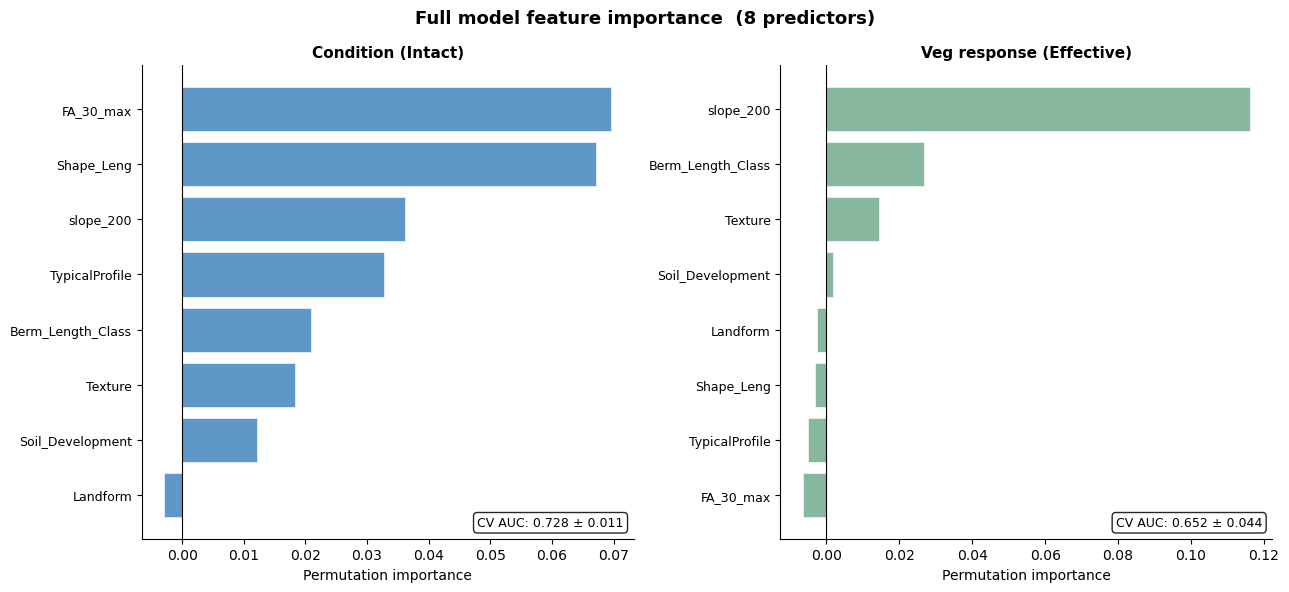

Updated → ../latex/figure_report_outcomes.tex  (RF Binary — feature importance)
Saved: fig_rf_binary_importance.png


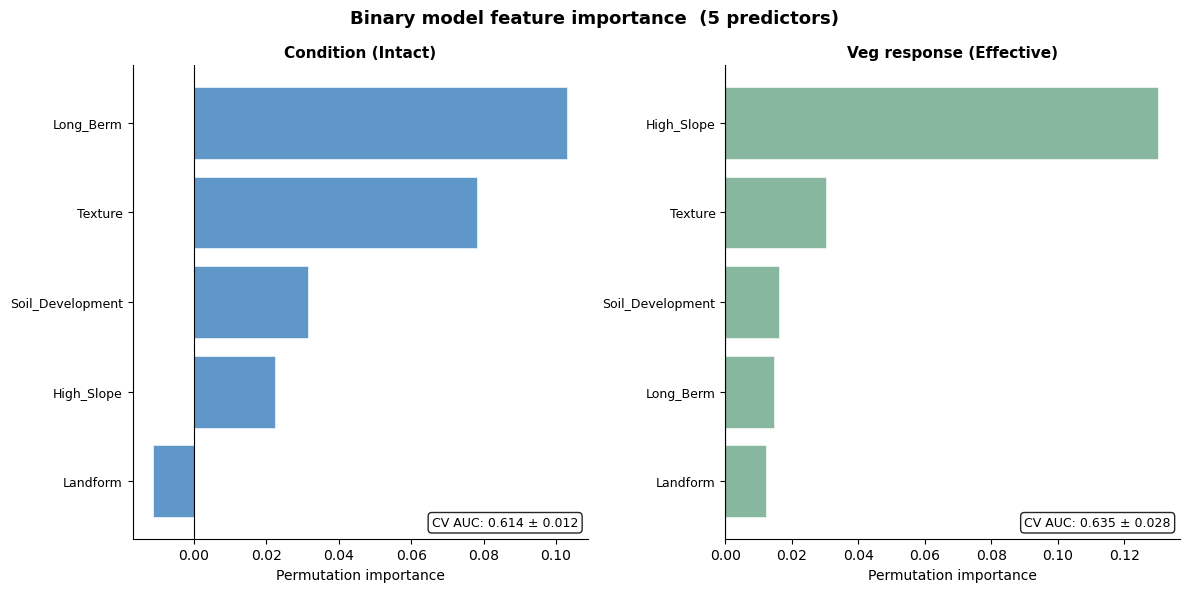

In [ ]:
# ── Visualize RF feature importance ─────────────────────────────────────────
# Two separate figures, each with Intact | Effective side by side:
#   fig_full   → Full model
#   fig_binary → Binary model
_N_FEAT = 8

def _single_target_panel(ax, importance_series, target_label, color, metrics):
    """Horizontal bar chart for one target's feature importance."""
    imp = importance_series.head(_N_FEAT)
    y = np.arange(len(imp))

    ax.barh(y, imp.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance', fontsize=10)
    ax.set_title(target_label, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    auc = metrics["cv"]["auc"]
    ax.text(0.98, 0.02, f"CV AUC: {auc[0]:.3f} ± {auc[1]:.3f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))


_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

auc_full_int = results_full["Intact"]["metrics"]["cv"]["auc"][0]
auc_bin_int  = results_binary["Intact"]["metrics"]["cv"]["auc"][0]
auc_full_eff = results_full["Effective"]["metrics"]["cv"]["auc"][0]
auc_bin_eff  = results_binary["Effective"]["metrics"]["cv"]["auc"][0]
n_full = len(results_full["Intact"]["predictors"])
n_bin  = len(results_binary["Intact"]["predictors"])

# ── Figure 1: Full model ────────────────────────────────────────────────────
fig_full, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig_full.suptitle(f"Full model feature importance  ({n_full} predictors)",
                  fontsize=13, fontweight='bold')

_single_target_panel(ax1, results_full["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_full["Intact"]["metrics"])
_single_target_panel(ax2, results_full["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_full["Effective"]["metrics"])

plt.tight_layout()
_fig_name_full = 'fig_rf_full_importance.png'
fig_full.savefig(os.path.join(_fig_dir, _fig_name_full), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_full_importance',
    'RF Full — feature importance',
    _fig_name_full,
    f"""Full random forest model ({n_full} predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_full_int:.3f}; top predictors: {', '.join(results_full['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_full_eff:.3f}; top predictors: {', '.join(results_full['Effective']['importance'].head(3).index.tolist())}.
Negative importances indicate features that add no signal beyond correlated predictors (effectively zero importance).""",
    f"""Full model ({n_full} predictors) permutation importance: Condition CV AUC {auc_full_int:.3f}, Veg response CV AUC {auc_full_eff:.3f}. FA_30_max and Shape_Leng dominate for Condition; slope_200 dominates for Veg response."""
)
print(f"Saved: {_fig_name_full}")
plt.show()

# ── Figure 2: Binary model ──────────────────────────────────────────────────
fig_bin, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 6))
fig_bin.suptitle(f"Binary model feature importance  ({n_bin} predictors)",
                 fontsize=13, fontweight='bold')

_single_target_panel(ax3, results_binary["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_binary["Intact"]["metrics"])
_single_target_panel(ax4, results_binary["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_binary["Effective"]["metrics"])

plt.tight_layout()
_fig_name_bin = 'fig_rf_binary_importance.png'
fig_bin.savefig(os.path.join(_fig_dir, _fig_name_bin), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_binary_importance',
    'RF Binary — feature importance',
    _fig_name_bin,
    f"""Binary random forest model ({n_bin} simplified predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_bin_int:.3f}; top predictors: {', '.join(results_binary['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_bin_eff:.3f}; top predictors: {', '.join(results_binary['Effective']['importance'].head(3).index.tolist())}.
AUC loss vs full model: Condition {auc_full_int - auc_bin_int:.3f}, Veg response {auc_full_eff - auc_bin_eff:.3f}.""",
    f"""Binary model ({n_bin} predictors) permutation importance: Condition CV AUC {auc_bin_int:.3f}, Veg response CV AUC {auc_bin_eff:.3f}. Long_Berm and Texture lead for Condition; High_Slope dominates for Veg response."""
)
print(f"Saved: {_fig_name_bin}")
plt.show()


Updated → ../latex/figure_report_outcomes.tex  (RF Performance Comparison)

Second figure saved and registered: ../figures/outcomes/fig_rf_performance_comparison.png


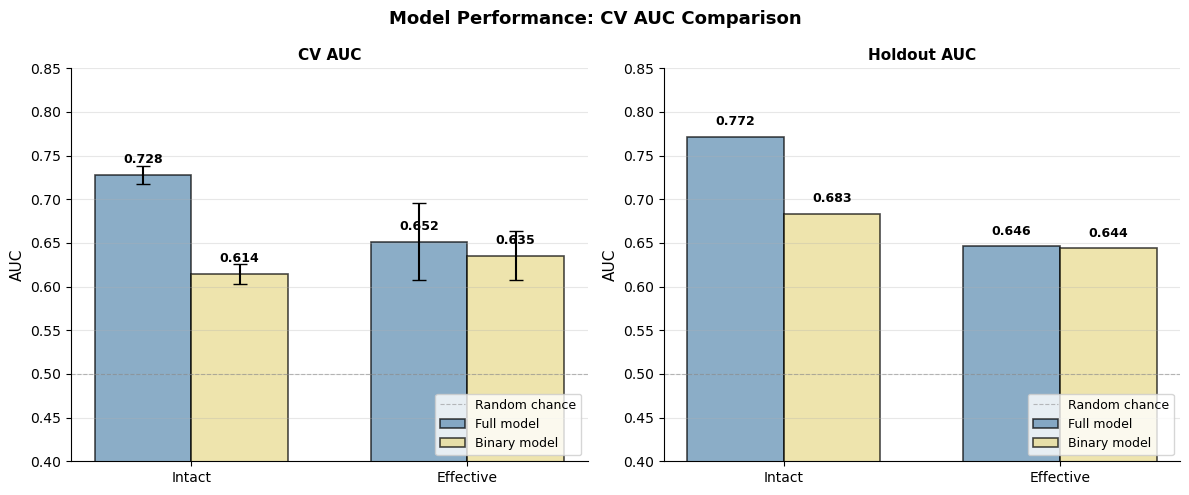

In [12]:
# ── Performance comparison bar chart ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Model Performance: CV AUC Comparison", fontsize=13, fontweight='bold')

targets = ["Intact", "Effective"]
x_pos = np.arange(len(targets))
bar_w = 0.35

for idx, metric_name in enumerate(["CV AUC", "Holdout AUC"]):
    ax = axes2[idx]
    
    # Extract metrics
    if metric_name == "CV AUC":
        full_vals = [results_full[t]["metrics"]["cv"]["auc"][0] for t in targets]
        full_errs = [results_full[t]["metrics"]["cv"]["auc"][1] for t in targets]
        bin_vals = [results_binary[t]["metrics"]["cv"]["auc"][0] for t in targets]
        bin_errs = [results_binary[t]["metrics"]["cv"]["auc"][1] for t in targets]
    else:  # Holdout AUC
        full_vals = [results_full[t]["metrics"]["holdout"]["auc"] for t in targets]
        full_errs = [0, 0]
        bin_vals = [results_binary[t]["metrics"]["holdout"]["auc"] for t in targets]
        bin_errs = [0, 0]
    
    # Plot bars
    bars1 = ax.bar(x_pos - bar_w/2, full_vals, bar_w, yerr=full_errs if metric_name == "CV AUC" else None,
                   label='Full model', capsize=5, color=INTACT_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x_pos + bar_w/2, bin_vals, bar_w, yerr=bin_errs if metric_name == "CV AUC" else None,
                   label='Binary model', capsize=5, color=DEGRADED_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for i, (b1, b2) in enumerate(zip(bars1, bars2)):
        ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.01, 
                f'{full_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.01,
                f'{bin_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(targets, fontsize=10)
    ax.set_ylim(0.4, 0.85)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random chance')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save second figure
_fig_name2 = 'fig_rf_performance_comparison.png'
_fig_path2 = os.path.join(_fig_dir, _fig_name2)
fig2.savefig(_fig_path2, dpi=300, bbox_inches='tight')

_delta = max(abs(auc_full_int - auc_bin_int), abs(auc_full_eff - auc_bin_eff))
register_outcomes_figure(
    'fig_rf_performance',
    'RF Performance Comparison',
    _fig_name2,
    f"""Bar chart comparison of model performance (CV AUC and Holdout AUC) for Full vs Binary random forest models on Intact and Effective outcomes.

Full model (n={len(results_full['Intact']['predictors'])} predictors): Intact CV AUC = {auc_full_int:.3f}, Effective CV AUC = {auc_full_eff:.3f}
Binary model (n={len(results_binary['Intact']['predictors'])} predictors): Intact CV AUC = {auc_bin_int:.3f}, Effective CV AUC = {auc_bin_eff:.3f}

Performance difference is minimal (max delta = {_delta:.3f} AUC), indicating that simplified binary predictors capture most of the signal. This validates using binary predictors for interpretability without substantial performance loss.""",
    f"""Model performance comparison showing Full vs Binary RF models achieve similar AUC scores (max delta = {_delta:.3f}). Binary model provides interpretable results with minimal performance sacrifice."""
)

print(f"\nSecond figure saved and registered: {_fig_path2}")
plt.show()


In [ ]:

# ── Feature selection: drop zero/negative-importance predictors and refit ──
# For each model version (Full, Binary) × target (Intact, Effective):
#   filter out predictors with mean permutation importance <= 0, refit, compare CV AUC.

_model_specs = {
    "Full":   {"results": results_full,   "df": df,        "treat_as": full_treat_as},
    "Binary": {"results": results_binary, "df": df_binary, "treat_as": binary_treat_as},
}

_pruned_rows = []
results_pruned = {}

for _model_name, _spec in _model_specs.items():
    print(f"\n{'='*60}")
    print(f"  Model: {_model_name}")
    print(f"{'='*60}")
    results_pruned[_model_name] = {}

    for _target in ["Intact", "Effective"]:
        _imp       = _spec["results"][_target]["importance"]
        _all_preds = _spec["results"][_target]["predictors"]
        _selected  = [p for p in _all_preds if _imp.get(p, 0) > 0]
        _dropped   = [p for p in _all_preds if p not in _selected]

        print(f"\n  ── {_target} ──")
        print(f"    All predictors  ({len(_all_preds)}): {_all_preds}")
        print(f"    Dropped (imp≤0) ({len(_dropped)}): {_dropped}")
        print(f"    Selected        ({len(_selected)}): {_selected}")

        if len(_selected) == 0:
            print("    ⚠  No positive-importance predictors — skipping refit.")
            continue

        _m_pruned, _metrics_pruned, _imp_pruned = fit_rf_binary(
            _spec["df"], y=_target, predictors=_selected,
            treat_as=_spec["treat_as"]
        )
        results_pruned[_model_name][_target] = {
            "model": _m_pruned, "metrics": _metrics_pruned,
            "importance": _imp_pruned, "predictors": _selected
        }

        _auc_before = _spec["results"][_target]["metrics"]["cv"]["auc"]
        _auc_after  = _metrics_pruned["cv"]["auc"]
        _delta      = _auc_after[0] - _auc_before[0]
        print(f"    AUC before: {_auc_before[0]:.3f} ± {_auc_before[1]:.3f}")
        print(f"    AUC after:  {_auc_after[0]:.3f} ± {_auc_after[1]:.3f}  (Δ {_delta:+.3f})")

        _pruned_rows.append({
            "Model":            _model_name,
            "Target":           _target,
            "N_predictors_all": len(_all_preds),
            "N_predictors_sel": len(_selected),
            "Dropped":          ", ".join(_dropped) if _dropped else "—",
            "AUC_full":         round(_auc_before[0], 3),
            "AUC_pruned":       round(_auc_after[0],  3),
            "Delta_AUC":        round(_delta, 3),
        })

_sel_df = pd.DataFrame(_pruned_rows)
print()
display(_sel_df)

# save comparison CSV
_sel_csv = "../data/summary/rf_feature_selection_comparison.csv"
_sel_df.to_csv(_sel_csv, index=False)
print(f"Saved: {_sel_csv}")



  Model: Full

  ── Intact ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (1): ['Landform']
    Selected        (7): ['slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']


    AUC before: 0.728 ± 0.011
    AUC after:  0.730 ± 0.017  (Δ +0.002)

  ── Effective ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (4): ['Landform', 'FA_30_max', 'TypicalProfile', 'Shape_Leng']
    Selected        (4): ['slope_200', 'Texture', 'Soil_Development', 'Berm_Length_Class']
    AUC before: 0.652 ± 0.044
    AUC after:  0.612 ± 0.034  (Δ -0.039)

  Model: Binary

  ── Intact ──
    All predictors  (5): ['High_Slope', 'Long_Berm', 'Landform', 'Soil_Development', 'Texture']
    Dropped (imp≤0) (1): ['Landform']
    Selected        (4): ['High_Slope', 'Long_Berm', 'Soil_Development', 'Texture']
    AUC before: 0.614 ± 0.012
    AUC after:  0.613 ± 0.012  (Δ -0.002)

  ── Effective ──
    All predictors  (5): ['High_Slope', 'Long_Berm', 'Landform', 'Soil_Development', 'Texture']
    Dropped (imp≤0) (0): []
    Selected        (5): ['High_Slope', 'Long_Ber

,Model,Target,N_predictors_all,N_predictors_sel,Dropped,AUC_full,AUC_pruned,Delta_AUC
0,Full,Intact,8,7,Landform,0.728,0.730,0.002
1,Full,Effective,8,4,"Landform, FA_30_max, TypicalProfile, Shape_Leng",0.652,0.612,-0.039
2,Binary,Intact,5,4,Landform,0.614,0.613,-0.002
3,Binary,Effective,5,5,—,0.635,0.635,0.000


Saved: ../data/summary/rf_feature_selection_comparison.csv


In [ ]:

# ---- Extra scenarios: effect_percent predicting Intact; Intact predicting Effective ----
base_all = scenario_predictors["all_predictors"]
extra_effective_runs = []

if "effect_percent" in df.columns:
    extra_effective_runs.append((
        "all_predictors + effect_percent", "Intact",
        _unique_preserve(base_all + ["effect_percent"])
    ))

if "Intact" in df.columns:
    extra_effective_runs.append((
        "all_predictors + Intact", "Effective",
        _unique_preserve(base_all + ["Intact"])
    ))

# Run extra scenarios and append to summary_rows
extra_log_lines = []
for scenario_name, target, predictors_run in extra_effective_runs:
    extra_log_lines.append(f"\n\n######## Extra: {scenario_name} / {target} ########")
    extra_log_lines.append(f"Predictors: {predictors_run}")
    try:
        model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors_run, treat_as=treat_as)
    except Exception as e:
        print(f"Skipping '{scenario_name}' / {target}: {e}")
        continue

    top3_str = ", ".join(pi.head(min(3, len(pi))).index.tolist())
    extra_log_lines.append(f"  cv_auc = {metrics['cv'].get('auc',(np.nan,np.nan))[0]:.4f}  top3 = {top3_str}")

    summary_rows.append({
        "scenario": scenario_name,
        "target": target,
        "cv_auc_mean": metrics["cv"].get("auc", (np.nan, np.nan))[0],
        "top_3_predictors": top3_str,
        "n": metrics["n"],
        "n_predictors": len(predictors_run),
        "cv_auc_sd": metrics["cv"].get("auc", (np.nan, np.nan))[1],
        "holdout_auc": metrics["holdout"].get("auc", np.nan),
        "cv_bal_acc_mean": metrics["cv"].get("bal_acc", (np.nan, np.nan))[0],
        "cv_f1_mean": metrics["cv"].get("f1", (np.nan, np.nan))[0],
    })

# Append extra log to file
results_txt = "../data/summary/scenario_model_results.txt"
with open(results_txt, "a") as f:
    f.write("\n".join(extra_log_lines))

# ---- Rebuild summary tables with reordered columns ----
col_order = [
    "scenario", "target", "cv_auc_mean", "top_3_predictors",
    "n", "n_predictors", "cv_auc_sd", "holdout_auc",
    "cv_bal_acc_mean", "cv_f1_mean",
]

scenario_summary = pd.DataFrame(summary_rows)
col_order = [c for c in col_order if c in scenario_summary.columns]

scenario_summary_effective = (
    scenario_summary.query("target == 'Effective'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)
scenario_summary_intact = (
    scenario_summary.query("target == 'Intact'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Effective ---")
display(scenario_summary_effective)
print("\n--- Intact ---")
display(scenario_summary_intact)



--- Effective ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Effective,0.651622,"slope_200, Berm_Length_Class, Texture",743,8,0.044287,0.645988,0.609234,0.581872
1,all_predictors + Intact,Effective,0.648915,"slope_200, Berm_Length_Class, Soil_Development",743,9,0.036397,0.649467,0.610157,0.580234
2,landscape_geomorphology_only,Effective,0.611614,"slope_200, Landform, FA_30_max",743,3,0.043323,0.680311,0.590170,0.570808
3,soil_only,Effective,0.578677,"TypicalProfile, Texture, Soil_Development",743,3,0.029888,0.621347,0.576589,0.542210
4,shape_length_only,Effective,0.558427,"Berm_Length_Class, Shape_Leng",743,2,0.036279,0.497449,0.532750,0.498728



--- Intact ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Intact,0.727806,"FA_30_max, Shape_Leng, slope_200",743,8,0.010714,0.771605,0.656144,0.707243
1,all_predictors + effect_percent,Intact,0.720881,"FA_30_max, Shape_Leng, slope_200",743,9,0.018664,0.770062,0.657340,0.715063
2,landscape_geomorphology_only,Intact,0.655780,"FA_30_max, slope_200, Landform",743,3,0.017483,0.679843,0.592318,0.668733
3,soil_only,Intact,0.627627,"TypicalProfile, Texture, Soil_Development",743,3,0.034388,0.618352,0.585442,0.695597
4,shape_length_only,Intact,0.564382,"Shape_Leng, Berm_Length_Class",743,2,0.017848,0.640966,0.541896,0.620880


In [ ]:
# Quick baseline CV AUC for both targets using all_predictors
_preds_quick = scenario_predictors["all_predictors"]
_, _met_int, _ = fit_rf_binary(df, y="Intact",    predictors=_preds_quick, treat_as=treat_as)
_, _met_eff, _ = fit_rf_binary(df, y="Effective", predictors=_preds_quick, treat_as=treat_as)

_auc_int = _met_int["cv"]["auc"]   # (mean, sd)
_auc_eff = _met_eff["cv"]["auc"]

print(f"Condition    CV AUC: {_auc_int[0]:.3f} ± {_auc_int[1]:.3f}  (n={_met_int['n']})")
print(f"Veg response CV AUC: {_auc_eff[0]:.3f} ± {_auc_eff[1]:.3f}  (n={_met_eff['n']})")

Condition    CV AUC: 0.728 ± 0.011  (n=743)
Veg response CV AUC: 0.652 ± 0.044  (n=743)
